#**3.4.1 Minimum Sapanning Trees**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/15jSSHYwFwQwb3XFAQ1jn3XQ3c7CYYnFM#scrollTo=jyBYKwAO4vqs)

Now consider a network problem in which we wish to select the fewest possible arcs in the network that will keep the graph connected. Recall that a graph is connected if there is at least one path between every pair of nodes. We furthermore want to select just those arcs with the smallest weights or costs. This is called the **minimum spanning tree problem**.

&nbsp;&nbsp;&nbsp;&nbsp;A typical application for a minimum spanning tree may arise in the design of a data communications network that includes processor nodes and numerous, possibly redundant, data links connecting the nodes in various ways. We would like to determine the set of data links, with the lowest total cost, that will maintain connectivity, so that there is some way to route data between any pair of nodes. Similarly, in any type of utility distribution network or transportation network, it may be desirable to identify the minimum set of connections to **span** the nodes.

&nbsp;&nbsp;&nbsp;&nbsp;Such a minimal set of arcs always forms a tree. Clearly, the inclusion of any arc resulting in a cycle would be a redundant arc, and this could not be a minimum spanning tree. To see this, suppose that the optimal solution contains a cycle. Select any arc (i, j) in the cycle, and delete it. Notice that any two nodes that were connected using arc (i, j) are still connected because nodes i and j are still connected by moving the other way around the cycle. Therefore, the solution could not have been optimal because we easily constructed a better, less costly one.

&nbsp;&nbsp;&nbsp;&nbsp;We present two algorithms for solving this problem. The choice of which one to use for a particular application depends on the density or sparsity of the network in question. The two algorithms are quite simple, and are sometimes called **greedy algorithms** because at each stage we make the decision that appears locally to be the best. In so doing, we finally arrive at an overall solution that is optimal. As has already been suggested, it is a rare and wonderful thing when we are able to solve combinatorial problems using simple greedy algorithms.

&nbsp;&nbsp;&nbsp;&nbsp;Our first solution to the minimum spanning tree problem is **Prim’s algorithm**, which operates by iteratively building a set of connected nodes as follows:

1. Arbitrarily select any node initially. Identify the node that is connected to the first node by the lowest cost arc. These two nodes now comprise the connected set, and the arc connecting them is a part of the minimum spanning tree.

2. Determine an isolated node that is *closest*, connected by the lowest cost arc, to some node in the connected set. Break ties arbitrarily. Add this node to the connected set of nodes and include the arc in the spanning tree. Repeat this step until no nodes remain isolated.

&nbsp;&nbsp;&nbsp;&nbsp;Prim’s algorithm is illustrated by the example shown in **Figure 3.11a**, where the sequence of pictures (b) through (e) shows the iterative construction of the minimum spanning tree. Node B is arbitrarily chosen as the initial node. Node C is its closest neighbor. Then node E is attached, followed by node D and finally node A. In the figure, nodes are outlined boldly as they become connected.

&nbsp;&nbsp;&nbsp;&nbsp;The arcs in the spanning tree have weights 1, 2, 4, and 5, yielding a cost of 12 for the minimal spanning tree. Note that the choice of initial node B is arbitrary, and any choice for the initial node would have yielded a tree whose cost is 12.

&nbsp;&nbsp;&nbsp;&nbsp;The complexity of Prim’s algorithm is O(n²) for an n-node network. If the network is sparse, with much less than n² arcs, the performance of this algorithm on large networks is unnecessarily slow. For such cases, we have an alternative algorithm, known as **Kruskal’s algorithm**, whose performance is O(e log e), where e is the number of arcs. Thus, in a sparse network where e is much less than n², Kruskal’s algorithm is superior; whereas in dense networks, Prim’s algorithm is preferred.

&nbsp;&nbsp;&nbsp;&nbsp;Kruskal’s algorithm operates by iteratively building up a set of arcs. We examine all the arcs, in increasing order of arc cost. For each arc, if the arc connects two nodes that are currently not connected, directly or indirectly, to each other, then the arc is included in the spanning tree. Otherwise, inclusion of the arc would cause a cycle and therefore could not be a part of a minimum spanning tree. This algorithm is another example of a greedy method. With Kruskal’s algorithm, we ensure a minimum cost tree by examining and choosing the lowest cost spanning arcs first. **Figure 3.12** shows the sequence of arcs chosen for a minimum spanning tree for the network in **Figure 3.12a**.

&nbsp;&nbsp;&nbsp;&nbsp;Tarjan provides a historical perspective on solutions to spanning tree problems, and describes several efficient variations to Prim’s and Kruskal’s algorithms. In such implementations, the improved complexity hinges on the use of specialized data structures, such as heaps and priority queues. Tarjan also discusses mechanisms for sensitivity analysis and determining if an algorithm is available for testing whether a given spanning tree is minimal, and it is also possible to determine how much the cost on each arc can be changed without affecting the minimality of the current spanning tree.

<br>

<div align="center">

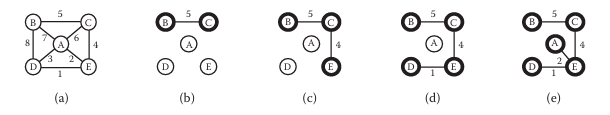

</div>

**FGURE 3.11** <br>
Prim’s algorithm: (a) original network, (b) first iteration, (c) second iteration, (d) third iteration, and (e) last iteration.

<br>

<div align="center">

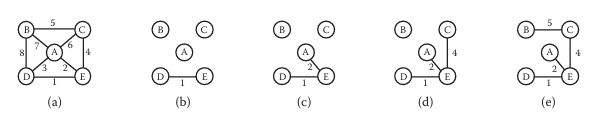

</div>

**FIGURE 3.12** <br>
Kruskal’s algorithm: (a) original network, (b) first iteration, (c) second iteration, (d) third iteration, and (e) last iteration.

<br>

&nbsp;&nbsp;&nbsp;&nbsp;It is interesting to note how difficult the minimum spanning tree problem becomes when certain constraints are added. If we place limits on the degree of all the nodes in the spanning tree, then the minimum spanning tree problem becomes NP-hard. Such restrictions might reasonably apply in an actual application, for example, where we could have a limited number of I/O ports on each microprocessor in a multiprocessor network.

In [7]:
# ========================================
# 3.4.1 Minimum Spanning Tree
# Book Example + Algebraic Method + Ready Function
# ========================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

print('Libraries loaded successfully.')
print('NetworkX version:', nx.__version__)


Libraries loaded successfully.
NetworkX version: 3.6.1


In [8]:
# ========================================
# Book Example — Figure 3.11 / 3.12
# Nodes A–E, start node B
# Expected MST cost = 12  (edges: B-C=1, C-E=2, D-E=4, A-D=5)
# ========================================

edge_list = [
    ('A', 'B', 7),
    ('A', 'D', 5),
    ('B', 'C', 1),
    ('B', 'D', 9),
    ('B', 'E', 6),
    ('C', 'E', 2),
    ('D', 'E', 4),
]

G = nx.Graph()
for u, v, w in edge_list:
    G.add_edge(u, v, weight=w)

print('Book example network created.')
df = pd.DataFrame(edge_list, columns=['From', 'To', 'Weight'])
print(df.to_string(index=False))


Book example network created.
From To  Weight
   A  B       7
   A  D       5
   B  C       1
   B  D       9
   B  E       6
   C  E       2
   D  E       4


In [9]:
# ========================================
# Algebraic Method: Manual Prim's & Kruskal's
# These implement the step-by-step greedy algorithms
# from the textbook, showing how the MST is built.
# ========================================

# ---------- Prim's Algorithm ----------
def prim_algorithm(nodes, edges, start):
    """
    Prim's algorithm: grow MST by always picking the
    cheapest edge connecting a new node to the current tree.
    """
    connected = [start]
    mst_edges = []
    total_cost = 0

    while len(connected) < len(nodes):
        best_edge = None
        best_cost = float('inf')

        for u, v, cost in edges:
            if (u in connected) != (v in connected):   # exactly one endpoint inside
                if cost < best_cost:
                    best_edge = (u, v, cost)
                    best_cost = cost

        mst_edges.append(best_edge)
        total_cost += best_cost
        u, v, _ = best_edge
        if u not in connected: connected.append(u)
        if v not in connected: connected.append(v)

    return mst_edges, total_cost


# ---------- Kruskal's Algorithm ----------
def find(parent, node):
    if parent[node] != node:
        parent[node] = find(parent, parent[node])
    return parent[node]

def union(parent, n1, n2):
    parent[find(parent, n2)] = find(parent, n1)

def kruskal_algorithm(nodes, edges):
    """
    Kruskal's algorithm: sort all edges by weight,
    add an edge if it connects two different components.
    """
    parent = {n: n for n in nodes}
    mst_edges = []
    total_cost = 0

    for u, v, cost in sorted(edges, key=lambda x: x[2]):
        if find(parent, u) != find(parent, v):
            mst_edges.append((u, v, cost))
            total_cost += cost
            union(parent, u, v)

    return mst_edges, total_cost


# ---------- Run both on the book example ----------
nodes = list(G.nodes())

prim_edges, prim_cost = prim_algorithm(nodes, edge_list, start='B')
kruskal_edges, kruskal_cost = kruskal_algorithm(nodes, edge_list)

print("=== Prim's Algorithm (start = B) ===")
display(pd.DataFrame(prim_edges, columns=['From', 'To', 'Weight']))
print(f'Total cost: {prim_cost}   {chr(10004) if prim_cost == 12 else chr(10008)}')

print()
print("=== Kruskal's Algorithm ===")
display(pd.DataFrame(kruskal_edges, columns=['From', 'To', 'Weight']))
print(f'Total cost: {kruskal_cost}   {chr(10004) if kruskal_cost == 12 else chr(10008)}')
print()
print('Textbook answer: cost = 12')


=== Prim's Algorithm (start = B) ===


,From,To,Weight
0,B,C,1
1,C,E,2
2,D,E,4
3,A,D,5


Total cost: 12   ✔

=== Kruskal's Algorithm ===


,From,To,Weight
0,B,C,1
1,C,E,2
2,D,E,4
3,A,D,5


Total cost: 12   ✔

Textbook answer: cost = 12


In [10]:
# ========================================
# Ready Function: nx.minimum_spanning_tree
# One call — returns the MST as a Graph object.
# Supports algorithm='kruskal' (default) or 'prim'.
# ========================================

# Kruskal's (default)
MST_kruskal = nx.minimum_spanning_tree(G, algorithm='kruskal')

# Prim's
MST_prim = nx.minimum_spanning_tree(G, algorithm='prim')

def mst_table(mst, label):
    rows = [(u, v, d['weight']) for u, v, d in sorted(mst.edges(data=True))]
    total = sum(r[2] for r in rows)
    print(f'=== {label} ===')
    display(pd.DataFrame(rows, columns=['From', 'To', 'Weight']))
    print(f'Total cost: {total}   {chr(10004) if total == 12 else chr(10008)}')
    print()

mst_table(MST_kruskal, "nx.minimum_spanning_tree — Kruskal's")
mst_table(MST_prim,    "nx.minimum_spanning_tree — Prim's")
print("Textbook answer: cost = 12  ✓")


=== nx.minimum_spanning_tree — Kruskal's ===


,From,To,Weight
0,A,D,5
1,B,C,1
2,C,E,2
3,D,E,4


Total cost: 12   ✔

=== nx.minimum_spanning_tree — Prim's ===


,From,To,Weight
0,A,D,5
1,B,C,1
2,C,E,2
3,D,E,4


Total cost: 12   ✔

Textbook answer: cost = 12  ✓
